
# Cálculo de Órbitas Galácticas de Estrellas con Gala

## Autor
Maria Alejandra Moreno Ramírez





In [2]:
# astropy imports
import astropy.coordinates as coord
from astropy.table import QTable
import astropy.units as u
from astroquery.gaia import Gaia

# Third-party imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# gala imports
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic

## Usando `astroquery` para traer los datos de GIA



Las coordenadas celestes `ra` (ascensión recta) y `dec` (declinación) indican la posición de una estrella en el cielo. El paralaje (`parallax`) permite calcular su distancia con la fórmula \( d = 1/p \), donde \( p \) está en segundos de arco. Los movimientos propios (`pmra`, `pmdec`) describen el cambio de posición en el tiempo, y junto con la velocidad radial, permiten obtener el movimiento tridimensional de la estrella y estudiar su órbita en la galaxia.

In [ ]:
query_text = '''SELECT TOP 4096 ra, dec, parallax, pmra, pmdec, radial_velocity, dec
phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr2.gaia_source
WHERE parallax_over_error > 10 AND
    parallax > 10 AND
    radial_velocity IS NOT null
ORDER BY random_index
'''

We now pass this query to the `Gaia.launch_job()` class method to create an anonymous job in the `Gaia` science archive to run our query. To retrieve the results of this query as an Astropy `Table` object, we then use the `job.get_results()` method. Note that you may receive a number of warnings (output lines that begin with ``WARNING:``) from the ``astropy.io.votable`` package — these are expected, and it's OK to ignore these warnings (the `Gaia` archive returns a slightly invalid VOTable).

In [5]:
# Note: the following lines require an internet connection, so we have 
# provided the results of this query as a FITS file included with the 
# tutorials repository. If you have an internet connection, feel free
# to uncomment these lines to retrieve the data with `astroquery`:
job = Gaia.launch_job(query_text)
gaia_data = job.get_results()
gaia_data.write('gaia_data.fits')

The `data` object is now an Astropy `Table` called `gaia_data` that contains `Gaia` data for 4096 random stars within 100 pc (or with a parallax > 10 mas) of the Sun, as we requested. Let's look at the first four rows of the table:

In [7]:
gaia_data[:10
          ]

ra,dec,parallax,pmra,pmdec,radial_velocity,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
deg,deg,mas,mas / yr,mas / yr,km / s,mag,mag,mag
float64,float64,float64,float64,float64,float64,float32,float32,float32
256.8370985186671,46.5081010273448,10.770964834345387,-19.76657104695835,55.92605676622464,-17.673072044811907,12.956913,14.192928,11.859498
129.45826809010867,-6.806694022293258,41.081670013380716,-297.34595349374183,43.83424795415093,35.53814452290586,6.576352,6.931065,6.111273
2.317856723637118,9.00699655780345,17.824765284426462,-171.8278607514459,-1083.8740928197751,-148.91780163518774,13.119075,13.968703,12.223303
330.41287472805976,51.88897801553169,13.0756133009657,-85.30745872006916,-34.23366534215265,-28.726469345049587,12.101919,13.0526495,11.149786
147.19500733390703,64.89446697480156,16.93304725892566,2.382528916102615,35.3422776993022,-19.67434662793379,7.00129,7.2429867,6.664537
80.2154121697551,-4.698409026669147,10.952733453482963,94.43034433086909,-51.11033017381004,23.14373705062893,11.307271,11.843748,10.633876
130.85357387757685,-44.02677884321,10.279167265645267,-25.154708979027845,17.61973693017641,40.91502127360303,10.926985,11.411972,10.315131
339.83848696327334,57.35583655498077,11.431122594578381,-88.0760523216923,-46.024711850345625,1.0253186600965876,11.903913,12.650127,11.08852


Note that the table columns already contain units! They are indicated in the second row of the header.

## Using `astropy.coordinates` to represent and transform stellar positions and velocities

Let's double check that the farthest star is still within 100 pc, as we expect from the parallax selection we did in the query above. To do this, we'll create an Astropy `Distance` object using the parallax (*Note: this inverts the parallax to compute the distance! This is only a good approximation when the parallax signal to noise is large, as we ensured in the query above with `parallax_over_error > 10`*):

In [8]:
dist = coord.Distance(parallax=u.Quantity(gaia_data['parallax']))
dist.min(), dist.max()

(<Distance 8.79909291 pc>, <Distance 99.99985292 pc>)

It looks like the closest star in our sample is about 9 pc away, and the farthest is almost 100 pc, as we expected.

We next want to convert the coordinate position and velocity data from heliocentric, spherical values to Galactocentric, Cartesian values. We'll do this using the [Astropy coordinates](http://docs.astropy.org/en/latest/coordinates/index.html) transformation machinery. To make use of this functionality, we first have to create a `SkyCoord` object from the `Gaia` data we downloaded. The `Gaia` DR2 data are in the ICRS (equatorial) reference frame, which is also the default frame when creating new `SkyCoord` objects, so we don't need to specify the frame below:

In [9]:
c = coord.SkyCoord(ra=gaia_data['ra'], 
                   dec=gaia_data['dec'],
                   distance=dist,
                   pm_ra_cosdec=gaia_data['pmra'], 
                   pm_dec=gaia_data['pmdec'],
                   radial_velocity=gaia_data['radial_velocity'])

Note: as described in the [Gaia DR2 data model](https://gea.esac.esa.int/archive/documentation/GDR2/Gaia_archive/chap_datamodel/sec_dm_main_tables/ssec_dm_gaia_source.html), the Gaia column `pmra` contains the cos(dec) term. In Astropy coordinates, the name of this component is `pm_ra_cosdec`.

Let's again look at the first four coordinates in the `SkyCoord` object:

In [11]:
c[:100]

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(256.83709852,  46.50810103, 92.84219338),
     (129.45826809,  -6.80669402, 24.3417563 ),
     (  2.31785672,   9.00699656, 56.1017205 ),
     (330.41287473,  51.88897802, 76.47824825),
     (147.19500733,  64.89446697, 59.05611581),
     ( 80.21541217,  -4.69840903, 91.3014093 ),
     (130.85357388, -44.02677884, 97.28414512),
     (339.83848696,  57.35583655, 87.48047199),
     (170.28871073,  -0.63123771, 77.69922824),
     ( 61.31355138, -64.50228726, 74.51482799),
     (260.2230614 , -41.29596747, 96.02014794),
     (178.95824295, -38.2816417 , 22.90078275),
     (189.46500466, -10.15327351, 66.79534923),
     (305.41064156, -49.99753307, 31.17485944),
     (177.70737956,  10.88707501, 83.97214306),
     (242.77447129,  49.42726953, 92.09481843),
     (258.34629331, -53.10556831, 42.15467375),
     ( 30.31263102,  -0.24004838, 77.47522559),
     (336.37997378, -15.59872421, 91.3449903 ),
     (179.8819221 ,   3.62959748

Now that we have a `SkyCoord` object with the Gaia data, we can transform to other coordinate systems. For example, we can transform to the `Galactic` coordinate system (centered on the Sun but with the zero latitude approximately aligned with the Galactic plane) using the `.galactic` attribute (this works for any of the [built-in Astropy coordinate frames](http://docs.astropy.org/en/latest/coordinates/index.html#reference-api), e.g., `.fk5` should also work):

In [12]:
c.galactic[:4]

<SkyCoord (Galactic): (l, b, distance) in (deg, deg, pc)
    [( 72.32926334,  36.8367097 , 92.84219338),
     (232.07542475,  19.9763116 , 24.3417563 ),
     (105.68646983, -52.44715126, 56.1017205 ),
     ( 98.28701089,  -2.66800849, 76.47824825)]
 (pm_l_cosb, pm_b, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(  55.13035551,   21.88801174,  -17.67307204),
     (-195.30630898, -228.4545973 ,   35.53814452),
     (-455.13470935, -998.57912013, -148.91780164),
     ( -88.74713695,   23.94268239,  -28.72646935)]>

The `Galactic` frame is still centered on the solar system barycenter, whereas we want to compute the positions and velocities of our sample of stars in a Galactocentric frame, centered on the center of the Milky Way. To do this transformation, Astropy provides the `Galactocentric` frame class, which allows us to use our own conventions for, e.g., the distance from the sun to the Galactic center (`galcen_distance`) or the height of the Sun over the Galactic midplane (`z_sun`). Let's look at the default values for the solar position and velocity:

In [13]:
coord.Galactocentric()

<Galactocentric Frame (galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg)>

We'll instead use a distance of 8.1 kpc — more consistent with the [recent results from the GRAVITY collaboration](https://arxiv.org/abs/1807.09409) — and a solar height of 0 pc. We'll use the default solar velocity (see output above). We can transform our data to this frame using the `transform_to()` method by specifying the `Galactocentric` frame with our adopted values:

In [14]:
galcen = c.transform_to(coord.Galactocentric(z_sun=0*u.pc, 
                                             galcen_distance=8.1*u.kpc))

The `galcen` object now contains the data for our sample, but in the Galactocentric frame:

In [15]:
galcen[:4]

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.1 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=0.0 pc, roll=0.0 deg): (x, y, z) in pc
    [(-8077.44468803,  70.79989896,  55.66242071),
     (-8114.06090109, -18.04601124,   8.31586669),
     (-8109.24493623,  32.92015736, -44.47693151),
     (-8111.0109288 ,  75.59768012,  -3.55986822)]
 (v_x, v_y, v_z) in km / s
    [(-16.26556759, 233.98501167,   4.89424163),
     (-30.94107553, 226.00094753,  -4.85474972),
     (210.89926667, -11.75804787, -36.02277769),
     ( 48.81632893, 222.24147077,  17.78803683)]>

We can access the positions of the stars using the `.x`, `.y`, and `.z` attributes, for example:

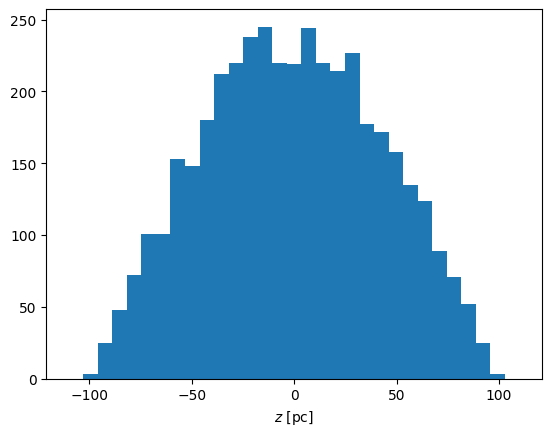

In [16]:
plt.hist(galcen.z.value, bins=np.linspace(-110, 110, 32))
plt.xlabel('$z$ [{0:latex_inline}]'.format(galcen.z.unit));

Similarly, for the velocity components, we can use `.v_x`, `.v_y`, and `.v_z`. For example, to create a classic "UV" plane velocity plot:

Text(0, 0.5, '$v_y$ [$\\mathrm{km\\,s^{-1}}$]')

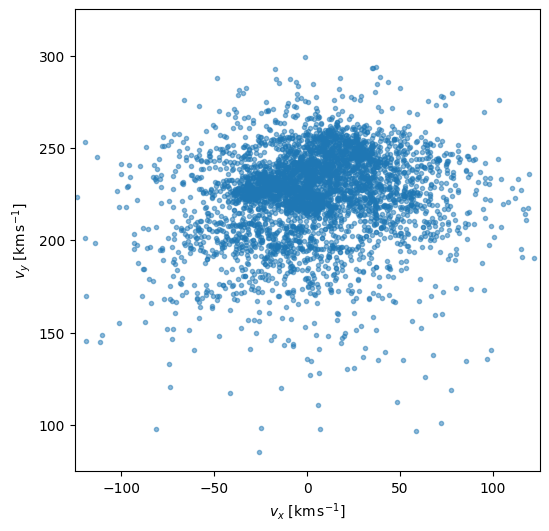

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(galcen.v_x.value, galcen.v_y.value,
        marker='.', linestyle='none', alpha=0.5)

ax.set_xlim(-125, 125)
ax.set_ylim(200-125, 200+125)

ax.set_xlabel('$v_x$ [{0:latex_inline}]'.format(u.km/u.s))
ax.set_ylabel('$v_y$ [{0:latex_inline}]'.format(u.km/u.s))

Along with astrometric and radial velocity data, `Gaia` also provides photometric data for three photometric bandpasses: the broad-band `G`, the blue `BP`, and the red `RP` magnitudes. Let's make a Gaia color-magnitude diagram using the $G_{\rm BP}-G_{\rm RP}$ color and the absolute $G$-band magnitude $M_G$. We'll compute the absolute magnitude using the distances we computed earlier — Astropy `Distance` objects have a convenient `.distmod` attribute that provides the distance modulus:

In [19]:
M_G = gaia_data['phot_g_mean_mag'] - dist.distmod
BP_RP = gaia_data['phot_bp_mean_mag'] - gaia_data['phot_rp_mean_mag']

Text(0, 0.5, '$M_G$')

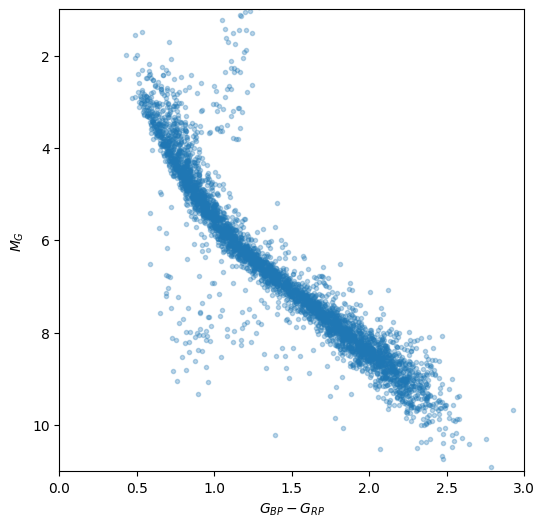

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(BP_RP.value, M_G.value, 
        marker='.', linestyle='none', alpha=0.3)

ax.set_xlim(0, 3)
ax.set_ylim(11, 1)

ax.set_xlabel('$G_{BP}-G_{RP}$')
ax.set_ylabel('$M_G$')

In the above, there is a wide range of main sequence star masses which have a range of lifetimes. The most massive stars were likely born in the thin disk and their orbits therefore likely have smaller vertical amplitudes than the typical old main sequence star. To compare, we'll create two sub-selections of the Gaia CMD to select massive and low-mass main sequence stars from the CMD for comparison. You may see two ``RuntimeWarning``(s) from running the next cell — these are expected and it's safe to ignore them.